머신러닝

In [9]:
# %pip install scikit-learn

In [10]:
# 1. 데이터 불러오기
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd

iris = load_iris()
X = iris.data        # 특성 (150, 4) numpy array
y = iris.target       # 라벨 (0, 1, 2)

X_train, X_test , y_train, y_test = train_test_split(X, y, test_size=0.2, random_state= 42)

In [21]:
y_test.shape

(30,)

In [22]:
X_train.shape

(120, 4)

In [23]:
X_test.shape

(30, 4)

In [26]:
# 1. 데이터 불러오기
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn import set_config
import numpy as np
import pandas as pd

set_config(display='text')  # Windows(cp949) 환경에서 estimator HTML diagram 읽기 시 UnicodeDecodeError 방지

iris = load_iris()
X = iris.data        # 특성 (150, 4) numpy array
y = iris.target       # 라벨 (0, 1, 2)

X_train, X_test , y_train, y_test = train_test_split(X, y, test_size=0.2, random_state= 42)

In [15]:
y_pred = model.predict(X_test)

In [16]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("정확도", accuracy_score( y_pred ,  y_test ))
print("분류 리포트", classification_report( y_pred ,  y_test ))
print("행렬\n", confusion_matrix( y_pred ,  y_test ))

정확도 1.0
분류 리포트               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

행렬
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


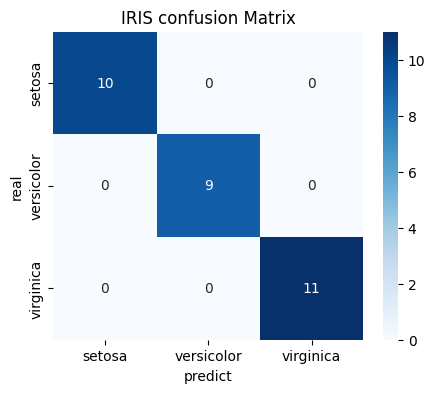

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(5,4))
cm = confusion_matrix( y_pred , y_test )
sns.heatmap(cm, annot=True, cmap='Blues', xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.xlabel('predict')
plt.ylabel('real')
plt.title("IRIS confusion Matrix")
plt.show()

간식분석

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import numpy as np
import pandas as pd

In [30]:
# 데이터
data = {
    '단맛': [
        # 초콜릿 20개: 단맛 6~9, 짠맛 2~4
        8, 7, 9, 6, 8, 7, 9, 8, 7, 6,
        8, 9, 7, 8, 6, 7, 8, 9, 7, 8,
        # 젤리 20개: 단맛 7~10, 짠맛 0~2  (초콜릿과 단맛 일부 겹침)
        9, 10, 8, 9, 10, 9, 8, 10, 9, 8,
        10, 9, 9, 8, 10, 9, 8, 9, 10, 9,
        # 감자칩 20개: 단맛 1~4, 짠맛 7~10
        2, 3, 1, 4, 2, 3, 1, 2, 3, 4,
        2, 1, 3, 2, 4, 1, 2, 3, 1, 2,
    ],
    '짠맛': [
        # 초콜릿: 짠맛 2~4
        3, 2, 4, 3, 2, 4, 3, 2, 3, 4,
        2, 3, 4, 3, 2, 3, 4, 2, 3, 2,
        # 젤리: 짠맛 0~2  (초콜릿과 짠맛 2 겹침 → 오분류 유발)
        1, 0, 2, 1, 0, 1, 2, 0, 1, 2,
        0, 1, 2, 1, 0, 1, 2, 0, 1, 2,
        # 감자칩: 짠맛 7~10
        8, 9, 8, 7, 10, 8, 9, 7, 8, 9,
        10, 8, 7, 9, 8, 9, 7, 8, 9, 8,
    ],
    '종류': ['초콜릿']*20 + ['젤리']*20 + ['감자칩']*20
}


df = pd.DataFrame(data)

# 입력/ 출력을 분리 , feature와 target을 분리
X = df[["단맛","짠맛"]]
y = df["종류"]

# 훈련/ 테스트 데이터로 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# KNN 분류기
model_knn = KNeighborsClassifier(n_neighbors=3)
model_knn.fit(X_train, y_train)
y_pred = model_knn.predict(X_test)
y_pred

# 정확도 출력
print("정확도", accuracy_score( y_pred , y_test ))


정확도 0.8333333333333334


In [31]:
# 내가 데이터 입력
# 단맛, 짠맛 8, 3 초콜릿
# 단맛, 짠맛 6, 6 ???
print(model_knn.predict(pd.DataFrame([[4,5]], columns=["단맛","짠맛"])))

['감자칩']
